# Figure 7

Power spectra, fitness-decay decompositions, and spectrum estimation. The explicit landscapes use tractable $A=2$ enumeration.

## Setup

In [4]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import subprocess
import sys
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.gridspec import GridSpec

from slide.utils import (
    FIGURE_LABEL_SIZE,
    FIGURE_LEGEND_SIZE,
    FIGURE_TICK_SIZE,
    FIGURE_TITLE_SIZE,
    PANEL_LETTER_SIZE,
    get_figures_dir,
    get_processed_data_dir,
    get_raw_data_dir,
    load_pickle,
    save_pickle,
)

OVERWRITE_RAW_PKL: bool = False
OVERWRITE_PROCESSED_PKL: bool = False
PLOT_ONLY: bool = True
SAVE_FIGURES: bool = True
PANEL_DPI: int = 350
SAVE_TYPES = ("pdf", "png", "eps")

RAW_DATA_DIR = get_raw_data_dir()
PROCESSED_DATA_DIR = get_processed_data_dir()
FIGURES_DIR = get_figures_dir()
REPO_ROOT = Path.cwd()
print(f"raw_data: {RAW_DATA_DIR}")
print(f"processed_data: {PROCESSED_DATA_DIR}")
print(f"figures: {FIGURES_DIR}")
print(f"PLOT_ONLY={PLOT_ONLY}, OVERWRITE_RAW_PKL={OVERWRITE_RAW_PKL}, OVERWRITE_PROCESSED_PKL={OVERWRITE_PROCESSED_PKL}")


def save_figure(fig: Figure, stem: str, *, bbox_inches: str = "tight") -> None:
    """Save a figure in PDF, PNG, and EPS formats.

    Parameters:
    - fig: Figure
        Matplotlib figure to save.
    - stem: str
        Filename stem without an extension.
    - bbox_inches: str
        Bounding-box mode passed to Matplotlib.

    Returns:
    - None
        Files are written below ``FIGURES_DIR``.
    """
    for suffix in SAVE_TYPES:
        destination = FIGURES_DIR / suffix
        destination.mkdir(parents=True, exist_ok=True)
        fig.savefig(destination / f"{stem}.{suffix}", dpi=PANEL_DPI, bbox_inches=bbox_inches)


def add_panel_letter(ax: Axes, letter: str) -> None:
    """Add a bold manuscript panel letter.

    Parameters:
    - ax: Axes
        Axis receiving the annotation.
    - letter: str
        Panel letter.

    Returns:
    - None
        The annotation is added directly to ``ax``.
    """
    ax.text(-0.14, 1.10, letter, transform=ax.transAxes, fontsize=PANEL_LETTER_SIZE,
            fontweight="bold", va="top", ha="left")

import jax.random as jr

from slide.direvo_functions import get_single_decay_rate
from slide.ruggedness_functions import (
    get_exp_matrix,
    get_fourier_coeffs,
    get_landscape_spectrum,
    get_nk_l_o_shape,
)

RAW_PATH = RAW_DATA_DIR / "figure7_nk_landscapes_raw.pkl"
PROCESSED_PATH = PROCESSED_DATA_DIR / "figure7_spectra_processed.pkl"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
raw_data: /home/lady5906/workspace_python/SLIDE/raw_data
processed_data: /home/lady5906/workspace_python/SLIDE/processed_data
figures: /home/lady5906/workspace_python/SLIDE/figures
PLOT_ONLY=True, OVERWRITE_RAW_PKL=False, OVERWRITE_PROCESSED_PKL=False


## Figure 7 Raw Products

In [5]:
def build_figure7_raw_payload() -> dict[str, object]:
    """Generate the tractable binary NK landscapes used by Figure 7.

    Returns:
    - dict[str, object]
        Raw synthetic landscapes and complete generation parameters.
    """
    n_sites, num_alleles, seed = 10, 2, 0
    k_values = (0, 3, 6, 9)
    shape = (num_alleles,) * n_sites
    base_key = jr.PRNGKey(seed)
    landscapes = [
        np.asarray(get_nk_l_o_shape(jr.fold_in(base_key, k_value), n_sites, k_value, shape))
        for k_value in k_values
    ]
    return {
        "data": {"landscapes": landscapes},
        "params": {"N": n_sites, "A": num_alleles, "K_values": k_values, "seed": seed},
        "metadata": {
            "paper_reference": "Figure 7",
            "description": "Binary explicit NK landscapes; A=2 is required for tractable 2^10 enumeration.",
        },
    }


if RAW_PATH.exists() and (PLOT_ONLY or not OVERWRITE_RAW_PKL):
    figure7_raw = load_pickle(RAW_PATH)
elif PLOT_ONLY:
    legacy_path = PROCESSED_DATA_DIR / "fourier_analysis.pkl"
    if not legacy_path.exists():
        raise FileNotFoundError(f"PLOT_ONLY=True requires {RAW_PATH} or {legacy_path}")
    legacy = load_pickle(legacy_path)
    figure7_raw = {
        "data": {"landscapes": legacy["nk_builts"]},
        "params": {"N": legacy["N_used"], "A": legacy["A_used"], "K_values": tuple(legacy["Ks_used"]), "seed": 0},
        "metadata": {"paper_reference": "Figure 7", "legacy_source": str(legacy_path)},
    }
else:
    figure7_raw = build_figure7_raw_payload()
    save_pickle(figure7_raw, RAW_PATH)


## Figure 7 Processing

In [6]:
def process_figure7_payload(raw_payload: dict[str, object]) -> dict[str, object]:
    """Compute Figure 7 spectra, decay decompositions, and spectrum estimates.

    Parameters:
    - raw_payload: dict[str, object]
        Raw Figure 7 NK landscapes.

    Returns:
    - dict[str, object]
        Fully processed arrays needed by panels A--E.
    """
    params = raw_payload["params"]
    n_sites = int(params["N"])  # type: ignore[index]
    num_alleles = int(params["A"])  # type: ignore[index]
    k_values = tuple(int(value) for value in params["K_values"])  # type: ignore[index]
    landscapes = raw_payload["data"]["landscapes"]  # type: ignore[index]
    spectra = [get_landscape_spectrum(item, norm=True, remove_constant=False, on_gpu=False) for item in landscapes]
    mutations = np.arange(0, 5.5, 0.5)
    exponentials = get_exp_matrix(N=n_sites, A=num_alleles, mutations=mutations, is_squared=True)
    decays, terms, fitted_decays, fitted_rhos = [], [], [], []
    estimates = {}
    for index, spectrum in enumerate(spectra):
        decay = np.dot(exponentials, spectrum)
        component_terms = exponentials * np.asarray(spectrum)[None, :]
        fit = get_single_decay_rate(decay, mut=0.5, num_steps=len(mutations))
        fitted = np.exp(-mutations * fit[0]) * (1 - fit[-1])
        decays.append(decay)
        terms.append(component_terms)
        fitted_decays.append(fitted)
        fitted_rhos.append(float(fit[0]))
        if index in (1, 3):
            rng = np.random.default_rng(2122)
            noisy = decay + rng.uniform(-0.05, 0.05, size=decay.shape)
            estimated, _ = get_fourier_coeffs(decay, mutations, n_sites, num_alleles, True,
                                               method="ls_constrained", fix_b0=True)
            noisy_estimate, _ = get_fourier_coeffs(noisy, mutations, n_sites, num_alleles, True,
                                                    method="nnls", fix_b0=True)
            regularised, _ = get_fourier_coeffs(noisy, mutations, n_sites, num_alleles, True,
                                                 method="nnls_reg", alpha=1e-3, fix_b0=True)
            estimates[index] = {
                "estimated": estimated,
                "noisy": noisy_estimate,
                "regularised": regularised,
            }
    return {
        "data": {
            "spectra": spectra, "mutations": mutations, "decays": decays,
            "terms": terms, "fitted_decays": fitted_decays, "fitted_rhos": fitted_rhos,
            "estimates": estimates,
        },
        "params": {"N": n_sites, "A": num_alleles, "K_values": k_values, "noise": 0.05},
        "metadata": {"paper_reference": "Figure 7"},
    }


if PROCESSED_PATH.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    figure7_payload = load_pickle(PROCESSED_PATH)
elif PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires processed payload {PROCESSED_PATH}")
else:
    figure7_payload = process_figure7_payload(figure7_raw)
    save_pickle(figure7_payload, PROCESSED_PATH)


## Individual Panels A–E

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


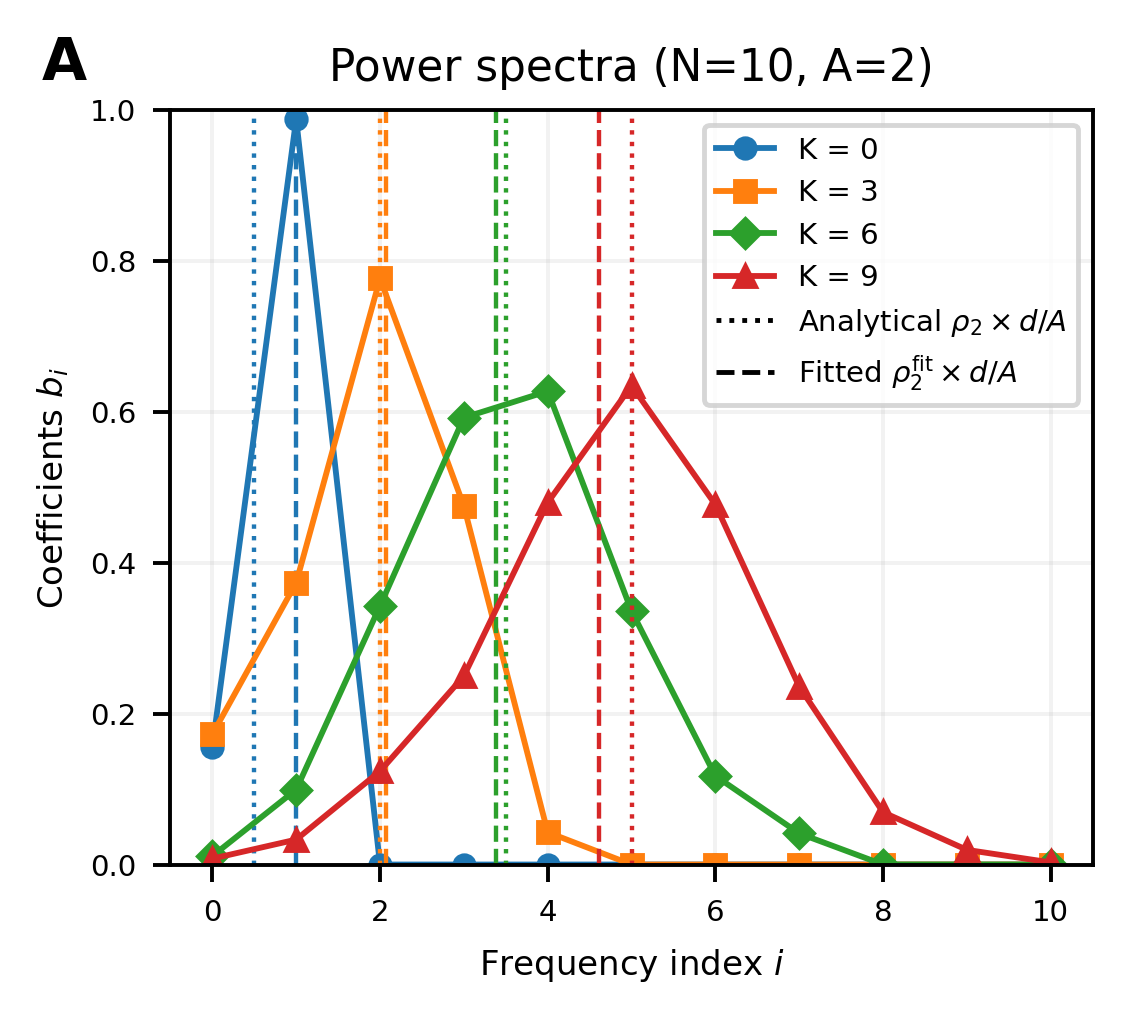

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


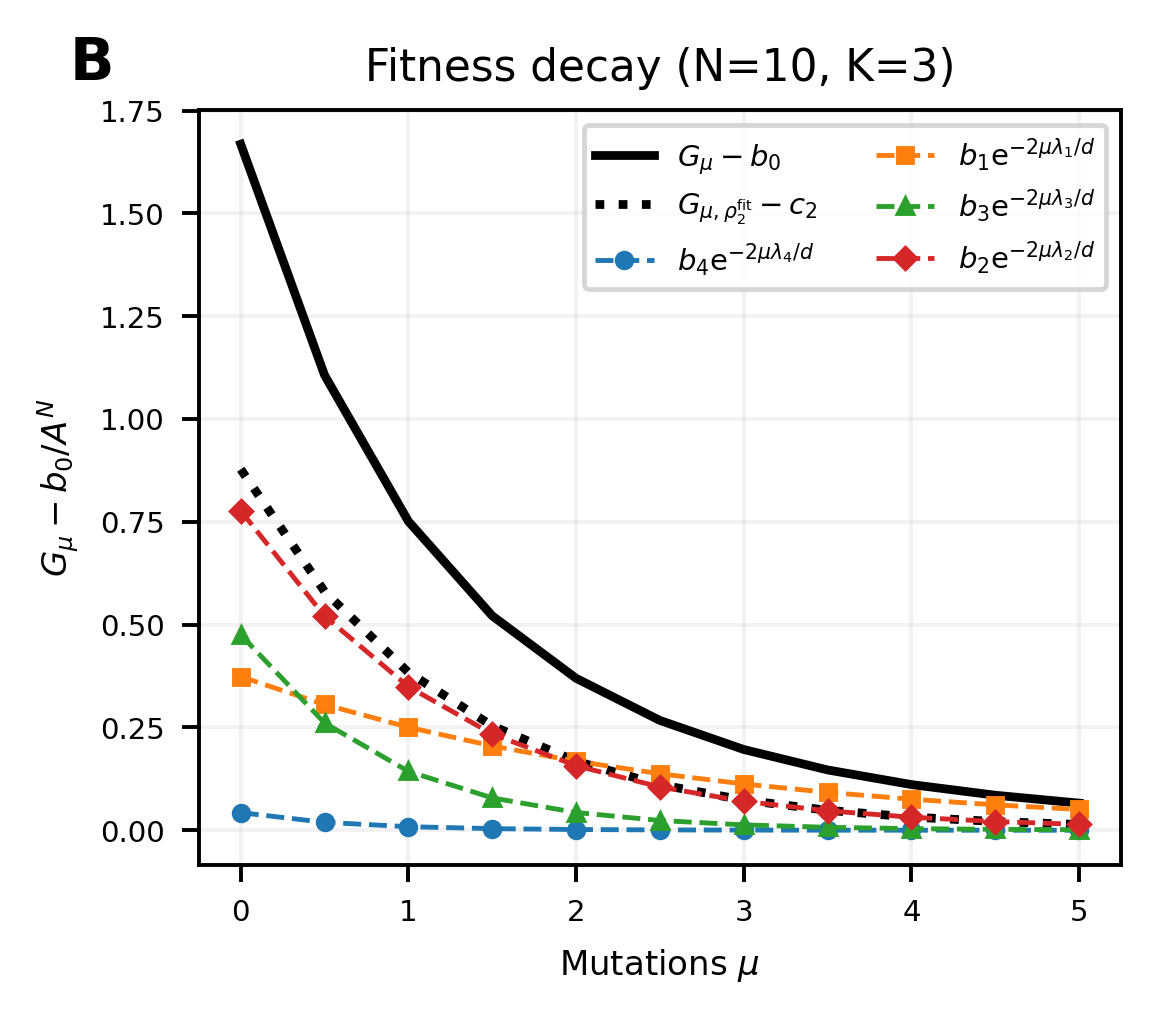

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


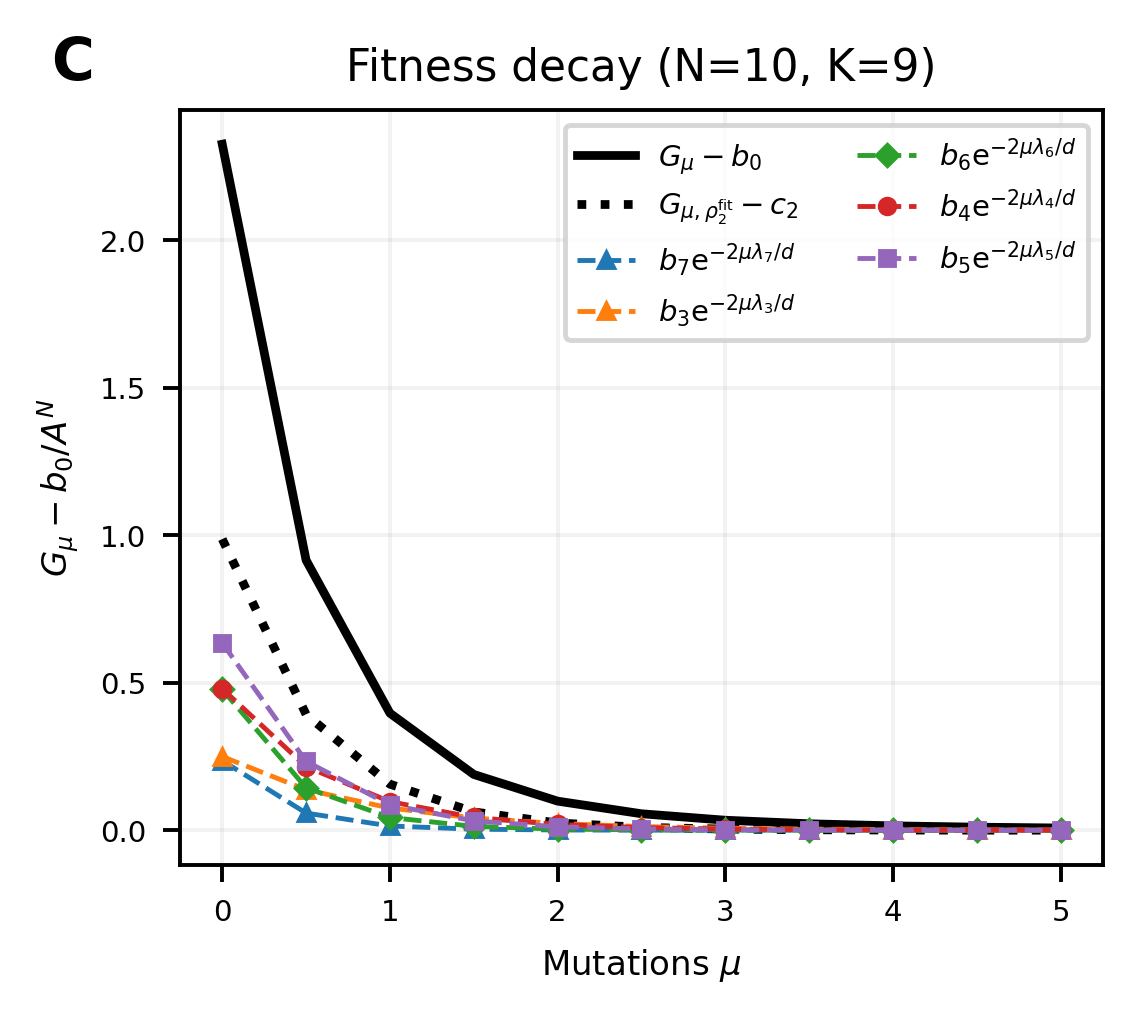

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


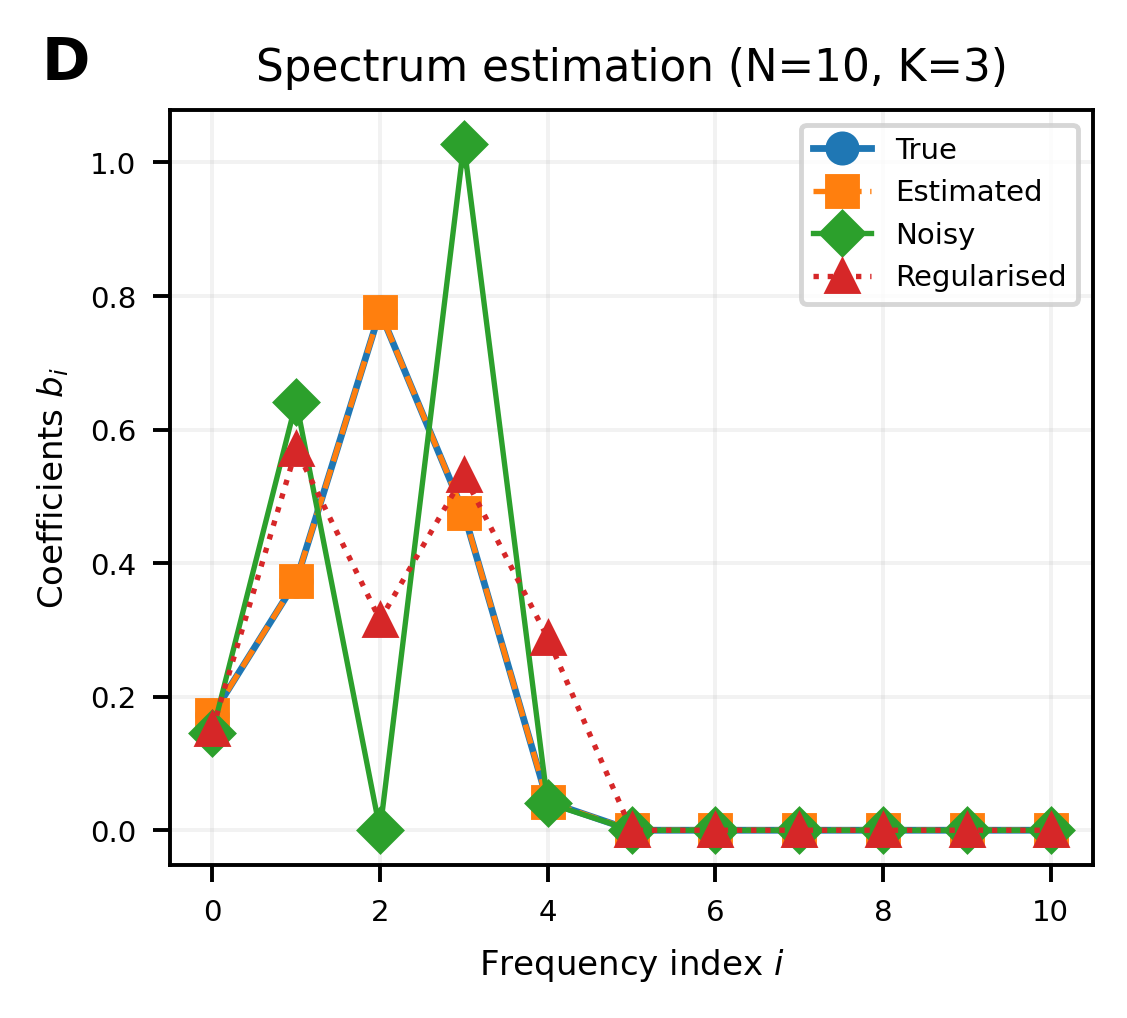

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


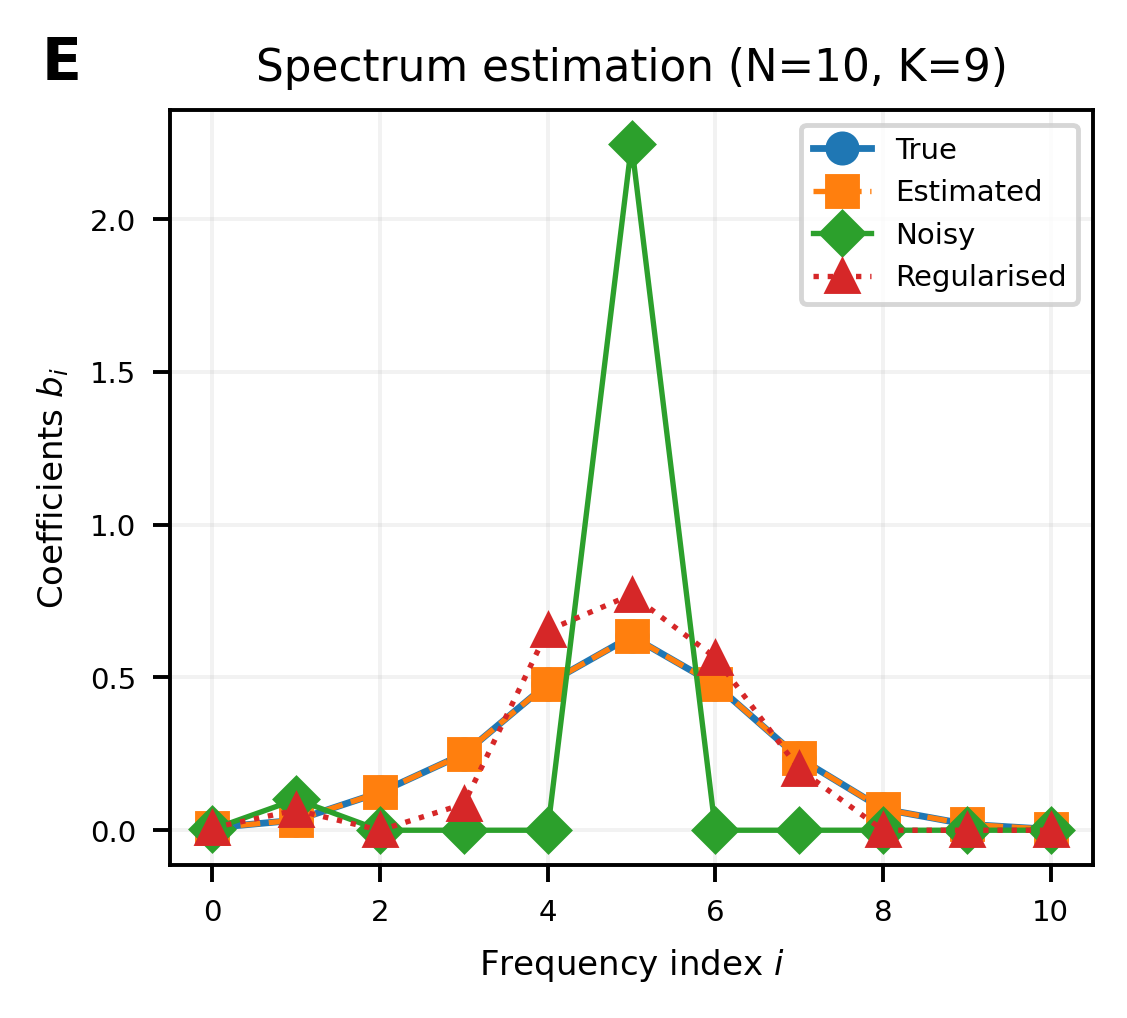

In [7]:
def plot_figure7_panel(ax: Axes, payload: dict[str, object], panel: str) -> None:
    """Plot one Figure 7 panel.

    Parameters:
    - ax: Axes
        Axis receiving the panel.
    - payload: dict[str, object]
        Processed Figure 7 payload.
    - panel: str
        Panel letter A--E.

    Returns:
    - None
        Panel artists are added to ``ax``.
    """
    data = payload["data"]
    params = payload["params"]
    spectra = data["spectra"]  # type: ignore[index]
    mutations = np.asarray(data["mutations"])  # type: ignore[index]
    k_values = tuple(params["K_values"])  # type: ignore[arg-type]
    markers = ("o", "s", "D", "^")
    if panel == "A":
        for index, (k_value, spectrum) in enumerate(zip(k_values, spectra, strict=True)):
            line, = ax.plot(range(len(spectrum)), spectrum, marker=markers[index], markersize=4,
                            linewidth=1.2, label=f"K = {k_value}")
            maximum = (k_value + 1) * (int(params["A"]) - 1) / int(params["A"])
            fitted_frequency = data["fitted_rhos"][index] * int(params["N"]) * (int(params["A"]) - 1) / (2 * int(params["A"]))  # type: ignore[index]
            ax.axvline(maximum, color=line.get_color(), linestyle=":", linewidth=0.9)
            ax.axvline(fitted_frequency, color=line.get_color(), linestyle="--", linewidth=0.9)
        ax.set_title(f"Power spectra (N={params['N']}, A={params['A']})", fontsize=FIGURE_TITLE_SIZE)
        ax.set_xlabel(r"Frequency index $i$", fontsize=FIGURE_LABEL_SIZE)
        ax.set_ylabel(r"Coefficients $b_i$", fontsize=FIGURE_LABEL_SIZE)
        ax.set_ylim(0, 1)
        handles, labels = ax.get_legend_handles_labels()
        handles.extend([
            mlines.Line2D([], [], color="black", linestyle=":", linewidth=1.0,
                          label=r"$\rho_{NK} \times d/A$"),
            mlines.Line2D([], [], color="black", linestyle="--", linewidth=1.0,
                          label=r"$\rho_2^{\mathrm{fit}} \times d/A$"),
        ])
        labels.extend([
            r"Analytical $\rho_2 \times d/A$",
            r"Fitted $\rho_2^{\mathrm{fit}} \times d/A$",
        ])
        ax.legend(handles=handles, labels=labels, fontsize=FIGURE_LEGEND_SIZE)
    elif panel in ("B", "C"):
        selected = 1 if panel == "B" else 3
        decay = np.asarray(data["decays"][selected])  # type: ignore[index]
        terms = np.asarray(data["terms"][selected])  # type: ignore[index]
        fitted = np.asarray(data["fitted_decays"][selected])  # type: ignore[index]
        ax.plot(mutations, decay - terms[0, 0], color="black", linewidth=1.8, label=r"$G_\mu-b_0$")
        ax.plot(mutations, fitted, color="black", linestyle=":", linewidth=1.8,
                label=r"$G_{\mu,\rho_2^{\mathrm{fit}}}-c_2$")
        dominant = np.argsort(np.asarray(spectra[selected]))[-5:]
        for component in dominant:
            if component == 0:
                continue
            ax.plot(mutations, terms[:, component], marker=markers[component % len(markers)],
                    markersize=3, linewidth=1.0, linestyle="--",
                    label=rf"$b_{{{component}}}\mathrm{{e}}^{{-2\mu\lambda_{{{component}}}/d}}$")
        ax.set_title(
            f"Fitness decay (N={params['N']}, K={k_values[selected]})",
            fontsize=FIGURE_TITLE_SIZE,
        )
        ax.set_xlabel(r"Mutations $\mu$", fontsize=FIGURE_LABEL_SIZE)
        ax.set_ylabel(r"$G_\mu-b_0/A^N$", fontsize=FIGURE_LABEL_SIZE)
        ax.legend(fontsize=FIGURE_LEGEND_SIZE, ncol=2)
    else:
        selected = 1 if panel == "D" else 3
        estimates = data["estimates"][selected]  # type: ignore[index]
        x_values = range(len(spectra[selected]))
        ax.plot(x_values, spectra[selected], marker="o", linewidth=1.4, label="True")
        ax.plot(x_values, estimates["estimated"], marker="s", linestyle="--", linewidth=1.1, label="Estimated")
        ax.plot(x_values, estimates["noisy"], marker="D", linewidth=1.1, label="Noisy")
        ax.plot(x_values, estimates["regularised"], marker="^", linestyle=":", linewidth=1.1, label="Regularised")
        ax.set_title(
            f"Spectrum estimation (N={params['N']}, K={k_values[selected]})",
            fontsize=FIGURE_TITLE_SIZE,
        )
        ax.set_xlabel(r"Frequency index $i$", fontsize=FIGURE_LABEL_SIZE)
        ax.set_ylabel(r"Coefficients $b_i$", fontsize=FIGURE_LABEL_SIZE)
        ax.legend(fontsize=FIGURE_LEGEND_SIZE)
    ax.tick_params(labelsize=FIGURE_TICK_SIZE)
    ax.grid(True, alpha=0.16)


for letter in "ABCDE":
    fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
    plot_figure7_panel(ax, figure7_payload, letter)
    add_panel_letter(ax, letter)
    if SAVE_FIGURES:
        save_figure(fig, f"figure_7{letter}")
    plt.show()


## Complete Figure 7

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


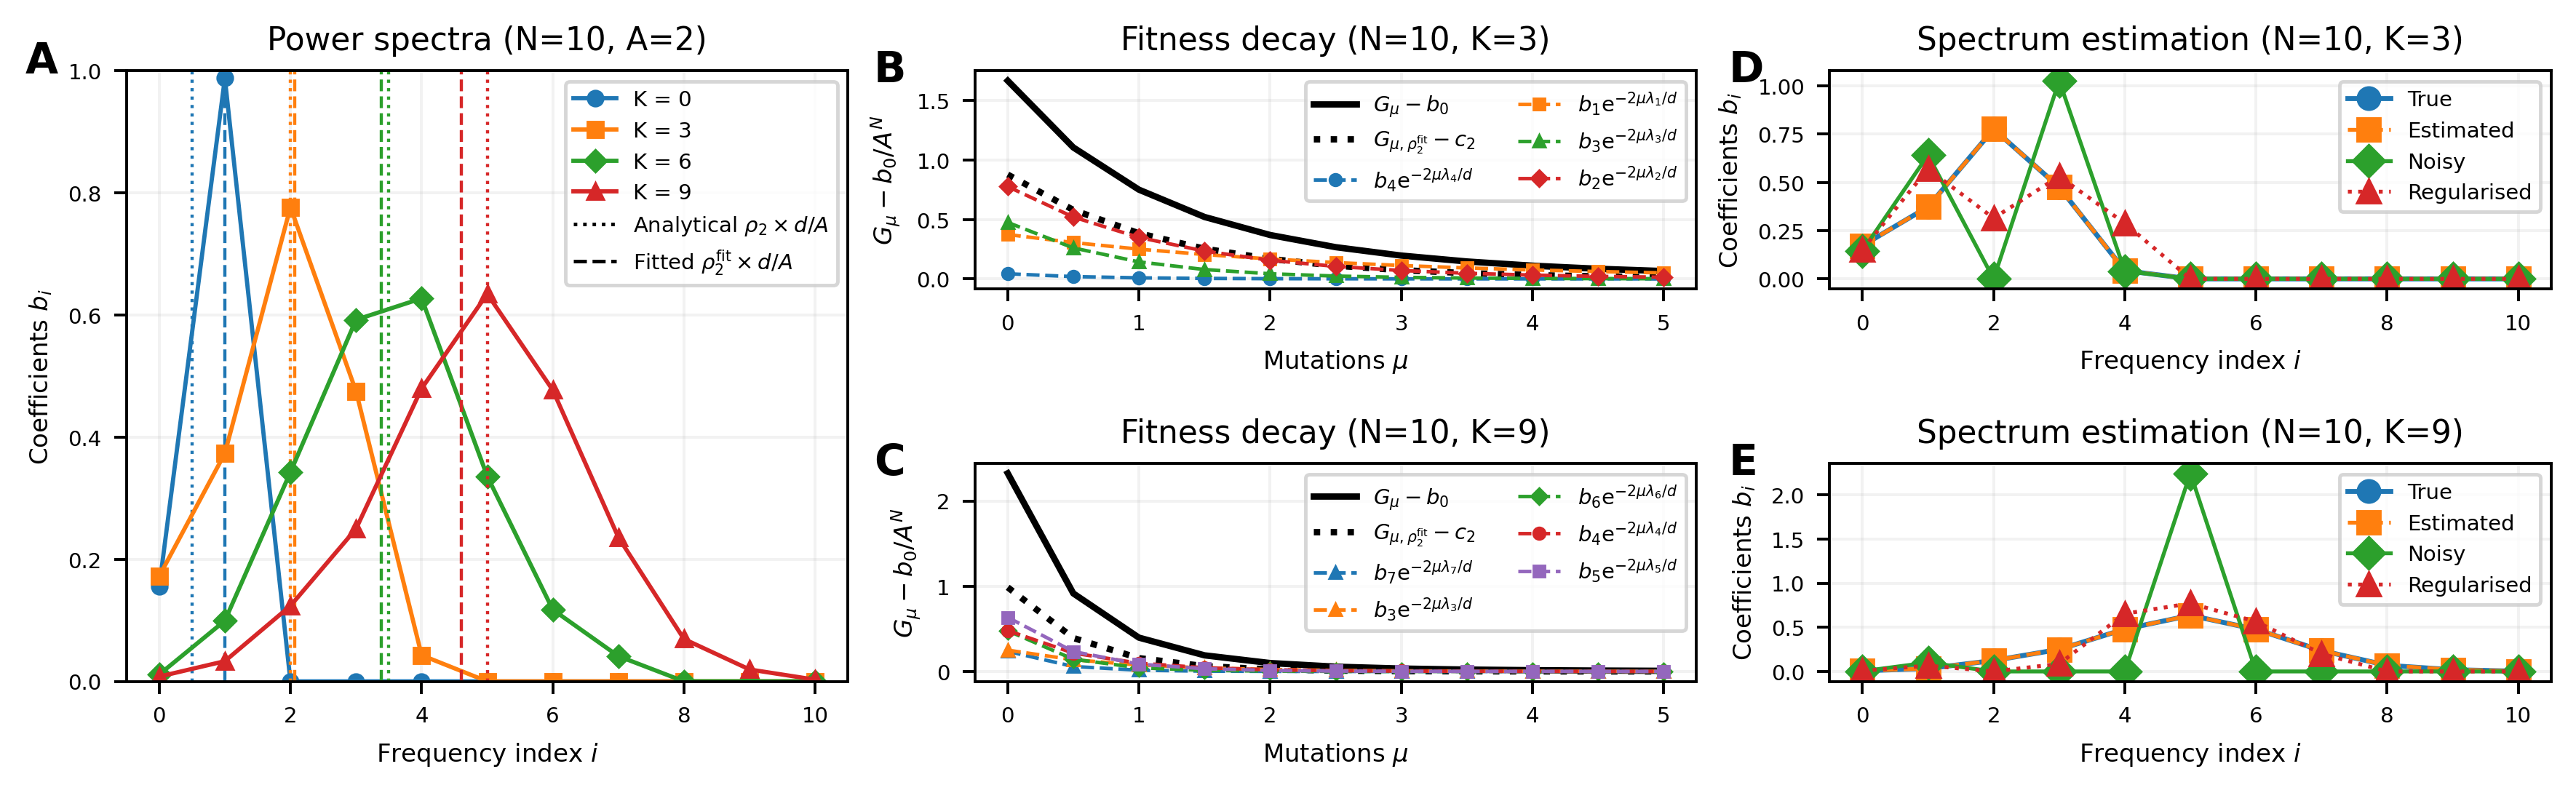

In [8]:
fig = plt.figure(figsize=(10, 3), dpi=PANEL_DPI, constrained_layout=True)
grid = GridSpec(2, 3, figure=fig)
axes = {
    "A": fig.add_subplot(grid[:, 0]),
    "B": fig.add_subplot(grid[0, 1]),
    "C": fig.add_subplot(grid[1, 1]),
    "D": fig.add_subplot(grid[0, 2]),
    "E": fig.add_subplot(grid[1, 2]),
}
for letter, ax in axes.items():
    plot_figure7_panel(ax, figure7_payload, letter)
    if letter == "A":
        ax.text(-0.14, 1.05, letter, transform=ax.transAxes, fontsize=PANEL_LETTER_SIZE,
                fontweight="bold", va="top", ha="left")
    else:
        add_panel_letter(ax, letter)
if SAVE_FIGURES:
    save_figure(fig, "figure_7")
plt.show()
